# 🏆 Revenue & COGS Forecasting — Complete Pro Notebook v5
> Bao gồm: EWMA · Fourier · Holiday Proximity · Log Transform  
> **V5 Focus**: Feature Selection (sớm) · Covariate Imputation · Seed Averaging · Multiplier Decoupling · Direct Forecasting (Lag >= 7)


## 1. Imports & Cấu hình


In [73]:
import numpy as np
import pandas as pd
import logging, warnings, joblib, os, shap, optuna, mlflow
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.linear_model    import Ridge, ElasticNet
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
from xgboost  import XGBRegressor
try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print("CatBoost not found (optional).")

from optuna.samplers import TPESampler
warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ─── Config ──────────────────────────────────────────────────────────────────
TRAIN_END    = "2021-12-31"
VAL_START    = "2022-01-01"
VAL_END      = "2022-12-31"
FULL_END     = "2022-12-31"
N_TRIALS     = 30
OOF_FOLDS    = 5
EMBARGO_DAYS = 2
LOG_TARGET   = True
DATA_DIR     = Path("../Data") if Path("../Data").exists() else Path("Data")
os.makedirs("logs",   exist_ok=True)
os.makedirs("models", exist_ok=True)

# ─── Logging ─────────────────────────────────────────────────────────────────
for h in logging.root.handlers[:]: logging.root.removeHandler(h)
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)-8s %(message)s",
    datefmt="%H:%M:%S",
    handlers=[logging.StreamHandler(),
              logging.FileHandler("logs/train_v5.log", mode="a", encoding="utf-8")])
log = logging.getLogger("nb")
log.info("Setup OK | CatBoost=%s | LOG_TARGET=%s", HAS_CATBOOST, LOG_TARGET)


22:50:25 INFO     Setup OK | CatBoost=True | LOG_TARGET=True


## 2. Tiện ích (Evaluate · Transform · Multiplier Tuning · SHAP)


In [74]:
# ── Log-transform helpers ──────────────────────────────────────────────────
def transform_target(y): return np.log1p(y) if LOG_TARGET else y
def inverse_transform(y): return np.expm1(y) if LOG_TARGET else y

# ── Evaluation ─────────────────────────────────────────────────────────────
def evaluate(y_true, y_pred, label=""):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2   = r2_score(y_true, y_pred)
    log.info(f"{label:<16}  MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  R2={r2:.4f}")
    return dict(mae=float(mae), rmse=float(rmse), r2=float(r2))

# ── Multiplier Tuning (Post-processing trick) ───────────────────────────────
def tune_multiplier(y_true, y_pred, low=0.95, high=1.05, steps=101):
    """Nhân predictions với constant để tối thiểu MAE trên Val."""
    best_k, best_mae = 1.0, mean_absolute_error(y_true, y_pred)
    for k in np.linspace(low, high, steps):
        m = mean_absolute_error(y_true, y_pred * k)
        if m < best_mae: best_mae, best_k = m, k
    log.info(f"  Multiplier k={best_k:.4f}  MAE_before={mean_absolute_error(y_true,y_pred):,.0f}  after={best_mae:,.0f}")
    return best_k

# ── SHAP ───────────────────────────────────────────────────────────────────
def plot_shap(model, X, title="SHAP", n=1000):
    expl = shap.TreeExplainer(model)
    sv   = expl.shap_values(X.tail(n))
    imp  = pd.Series(np.abs(sv).mean(axis=0), index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(10, 8))
    shap.summary_plot(sv, X.tail(n), show=False)
    plt.title(title); plt.tight_layout(); plt.show()
    return imp


## 3. DataLoader


In [75]:
class DataLoader:
    _FILES = {
        "sales":       ("sales.csv",       ["Date"]),
        "orders":      ("orders.csv",      ["order_date"]),
        "order_items": ("order_items.csv", []),
        "payments":    ("payments.csv",    []),
        "customers":   ("customers.csv",   ["signup_date"]),
        "products":    ("products.csv",    []),
        "promotions":  ("promotions.csv",  ["start_date","end_date"]),
        "inventory":   ("inventory.csv",   ["snapshot_date"]),
        "web_traffic": ("web_traffic.csv", ["date"]),
        "returns":     ("returns.csv",     ["return_date"]),
        "reviews":     ("reviews.csv",     ["review_date"]),
        "shipments":   ("shipments.csv",   ["ship_date","delivery_date"]),
        "geography":   ("geography.csv",   []),
    }
    def __init__(self, data_dir=DATA_DIR):
        self.data_dir = Path(data_dir)
        for attr,(fn,dc) in self._FILES.items():
            fp = self.data_dir/fn
            if not fp.exists(): setattr(self,attr,None); log.warning("Missing %s",fp); continue
            kw = {"parse_dates":dc} if dc else {}
            df = pd.read_csv(fp,**kw); setattr(self,attr,df)
            log.info("  Loaded %-25s %8d rows", fn, len(df))

data = DataLoader()


22:50:25 INFO       Loaded sales.csv                     3833 rows
22:50:26 INFO       Loaded orders.csv                  646945 rows
22:50:26 INFO       Loaded order_items.csv             714669 rows
22:50:26 INFO       Loaded payments.csv                646945 rows
22:50:26 INFO       Loaded customers.csv               121930 rows
22:50:26 INFO       Loaded products.csv                  2412 rows
22:50:26 INFO       Loaded promotions.csv                  50 rows
22:50:26 INFO       Loaded inventory.csv                60247 rows
22:50:26 INFO       Loaded web_traffic.csv               3652 rows
22:50:26 INFO       Loaded returns.csv                  39939 rows
22:50:27 INFO       Loaded reviews.csv                 113551 rows
22:50:27 INFO       Loaded shipments.csv               566067 rows
22:50:27 INFO       Loaded geography.csv                39948 rows


## 4. Feature Engineering (Direct Forecasting Focus - Lag >= 7)


In [76]:
TET_DATES = [
    pd.Timestamp("2012-01-23"), pd.Timestamp("2013-02-10"),
    pd.Timestamp("2014-01-31"), pd.Timestamp("2015-02-19"),
    pd.Timestamp("2016-02-08"), pd.Timestamp("2017-01-28"),
    pd.Timestamp("2018-02-16"), pd.Timestamp("2019-02-05"),
    pd.Timestamp("2020-01-25"), pd.Timestamp("2021-02-12"),
    pd.Timestamp("2022-02-01"), pd.Timestamp("2023-01-22"),
    pd.Timestamp("2024-02-10"),
]
SHOPPING_EVENTS = TET_DATES + [pd.Timestamp(f"{y}-{m}-{d}") for y in range(2013,2025) for m,d in [(11,11),(12,12)]]
SHOPPING_EVENTS = sorted(set(SHOPPING_EVENTS))
_evt_arr = np.array([e.value for e in SHOPPING_EVENTS])

def days_to_next_event(date):
    fut = _evt_arr[_evt_arr >= date.value]
    return int((fut.min() - date.value) / 86_400_000_000_000) if len(fut) else 365
def days_since_last_event(date):
    past = _evt_arr[_evt_arr <= date.value]
    return int((date.value - past.max()) / 86_400_000_000_000) if len(past) else 365

class FeatureEngineer:
    TARGETS = ["Revenue","COGS"]
    def __init__(self, data: DataLoader): self.data = data
    def build(self) -> pd.DataFrame:
        self.df = self.data.sales.copy().sort_values("Date").reset_index(drop=True)
        self._time(); self._fourier(); self._lag_rolling(); self._ewma()
        self._momentum(); self._holiday_proximity(); self._seasonal_flags()
        self._transactions(); self._web(); self._inventory(); self._promos()
        self.df = self.df.dropna(subset=["revenue_lag_365"]).reset_index(drop=True)
        return self.df

    def get_feature_cols(self): return [c for c in self.df.columns if c not in {"Date","Revenue","COGS"}]

    def _time(self):
        d = self.df["Date"]
        self.df["year"]          = d.dt.year
        self.df["month"]         = d.dt.month
        self.df["day"]           = d.dt.day
        self.df["day_of_week"]   = d.dt.dayofweek
        self.df["day_of_year"]   = d.dt.dayofyear
        self.df["week_of_year"]  = d.dt.isocalendar().week.astype(int)
        self.df["quarter"]       = d.dt.quarter
        self.df["is_weekend"]    = (self.df["day_of_week"] >= 5).astype(int)

    def _fourier(self):
        self.df["sin_month"] = np.sin(2*np.pi*self.df["month"]/12)
        self.df["cos_month"] = np.cos(2*np.pi*self.df["month"]/12)
        self.df["sin_dow"]   = np.sin(2*np.pi*self.df["day_of_week"]/7)
        self.df["cos_dow"]   = np.cos(2*np.pi*self.df["day_of_week"]/7)

    def _lag_rolling(self):
        rev = self.df["Revenue"]
        for lag in [7, 14, 30, 90, 365]: self.df[f"revenue_lag_{lag}"] = rev.shift(lag)
        for lag in [7, 30, 365]:         self.df[f"cogs_lag_{lag}"] = self.df["COGS"].shift(lag)
        rs = rev.shift(7)
        for w in [7, 14, 30, 90]:
            self.df[f"revenue_roll_mean_{w}"] = rs.rolling(w).mean()
            self.df[f"revenue_roll_std_{w}"]  = rs.rolling(w).std()
        self.df["revenue_diff_7_14"] = rev.shift(7) - rev.shift(14)
        
    def _ewma(self):
        rs = self.df["Revenue"].shift(7)
        for span in [7, 14, 30]:
            self.df[f"revenue_ewm_{span}"] = rs.ewm(span=span, min_periods=span//2).mean()

    def _momentum(self):
        df = self.df
        df["rev_diff_7_30"] = df["revenue_lag_7"] - df["revenue_lag_30"]
        df["cogs_rev_ratio"]= (df["cogs_lag_7"] / (df["revenue_lag_7"] + 1e-9)).clip(0,2)

    def _holiday_proximity(self):
        d = self.df["Date"]
        self.df["days_to_next_event"]   = d.apply(days_to_next_event)
        self.df["days_since_last_event"]= d.apply(days_since_last_event)
        self.df["is_pre_event_7d"]  = (self.df["days_to_next_event"] <= 7).astype(int)

    def _seasonal_flags(self):
        m, dow = self.df["Date"].dt.month, self.df["Date"].dt.dayofweek
        self.df["is_tet_period"]    = (((m==1)&(self.df["Date"].dt.day.between(15,31)))|((m==2)&(self.df["Date"].dt.day<=15))).astype(int)

    def _transactions(self):
        if self.data.orders is None or self.data.order_items is None: return
        orders,items = self.data.orders, self.data.order_items
        daily_ord = orders.groupby("order_date").agg(daily_order_count=("order_id","count")).reset_index().rename(columns={"order_date":"Date"})
        items_d = items.merge(orders[["order_id","order_date"]], on="order_id")
        daily_items = items_d.groupby("order_date").agg(
            daily_items_sold=("quantity","sum"),
            active_promo_rate=("promo_id", lambda x: x.notna().mean())
        ).reset_index().rename(columns={"order_date":"Date"})
        for dft in [daily_ord, daily_items]: self.df = self.df.merge(dft, on="Date", how="left")
        for col in ["daily_order_count","daily_items_sold","active_promo_rate"]:
            if col in self.df.columns: self.df[col] = self.df[col].fillna(self.df[col].shift(365))

    def _web(self):
        if self.data.web_traffic is None: return
        dw = self.data.web_traffic.groupby("date").agg(
            daily_sessions=("sessions","sum"),
            daily_page_views=("page_views","sum")
        ).reset_index().rename(columns={"date":"Date"})
        self.df = self.df.merge(dw, on="Date", how="left")
        for col in ["daily_sessions","daily_page_views"]:
            if col in self.df.columns:
                self.df[col] = self.df[col].fillna(self.df[col].shift(365)).fillna(self.df[col].median())

    def _inventory(self):
        if self.data.inventory is None: return
        inv = self.data.inventory.copy()
        inv["year"], inv["month"] = inv["snapshot_date"].dt.year, inv["snapshot_date"].dt.month
        mi = inv.groupby(["year","month"]).agg(monthly_total_stock=("stock_on_hand","sum")).reset_index()
        self.df = self.df.merge(mi, on=["year","month"], how="left")

    def _promos(self):
        if self.data.promotions is None: return
        promos = self.data.promotions
        def count_active(date):
            mask = (promos["start_date"]<=date)&(promos["end_date"]>=date)
            return pd.Series({"active_promo_count":len(promos[mask])})
        self.df = pd.concat([self.df, self.df["Date"].apply(count_active)], axis=1)

    def prepare_recursive_features(self, df_ext: pd.DataFrame) -> pd.DataFrame:
        orig = self.df
        self.df = df_ext[["Date","Revenue","COGS"]].copy()
        self._time(); self._fourier(); self._lag_rolling(); self._ewma()
        self._momentum(); self._holiday_proximity(); self._seasonal_flags()
        row = self.df.iloc[[-1]].copy()
        self.df = orig
        # Merge back untouched cols (transactions, web, inventory from Covariate Imputation)
        for c in orig.columns:
            if c not in row.columns and c in df_ext.columns:
                row[c] = df_ext.iloc[-1][c]
        # Fill missing with 0.0 as last resort
        for c in orig.columns:
            if c not in row.columns: row[c] = 0.0
        return row[orig.columns]

feature_eng = FeatureEngineer(data)
df = feature_eng.build()
FEATURES = feature_eng.get_feature_cols()
TARGETS  = ["Revenue","COGS"]

df_train = df[df.Date <= TRAIN_END].copy()
df_val   = df[(df.Date >= VAL_START)&(df.Date <= VAL_END)].copy()
X_train, y_train = df_train[FEATURES], df_train[TARGETS].apply(transform_target)
X_val,   y_val   = df_val[FEATURES],   df_val[TARGETS]
log.info("Train: %d | Val: %d", len(X_train), len(X_val))


22:50:29 INFO     Train: 3103 | Val: 365


## 5. Early Feature Selection (SHAP)


22:50:29 INFO     --- Fast Feature Selection (LGBM on full train) ---


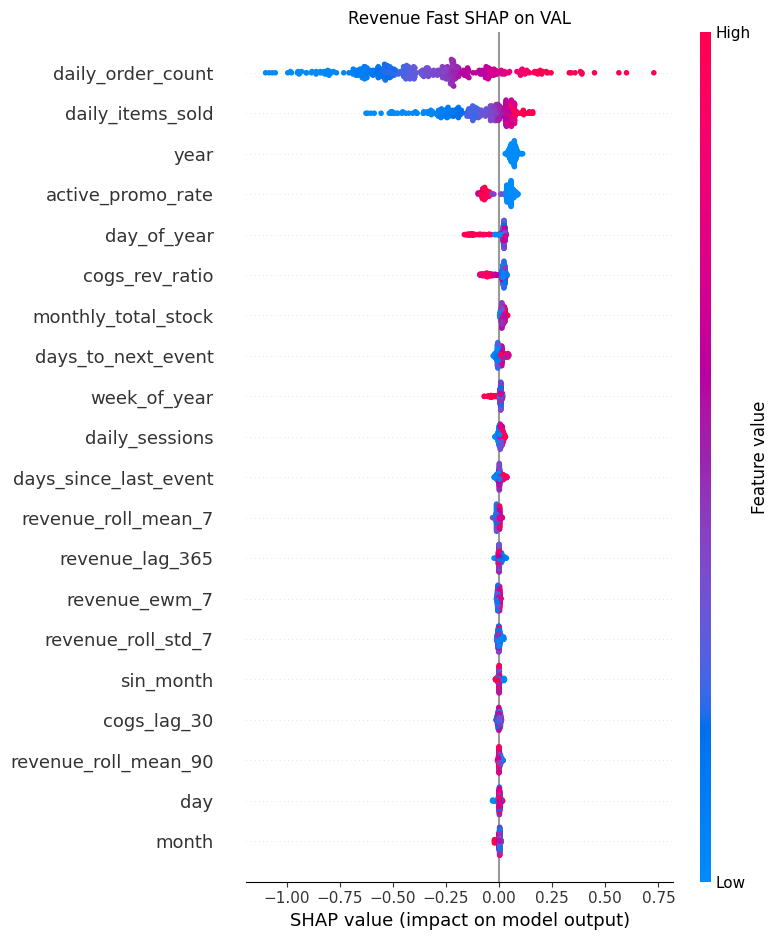

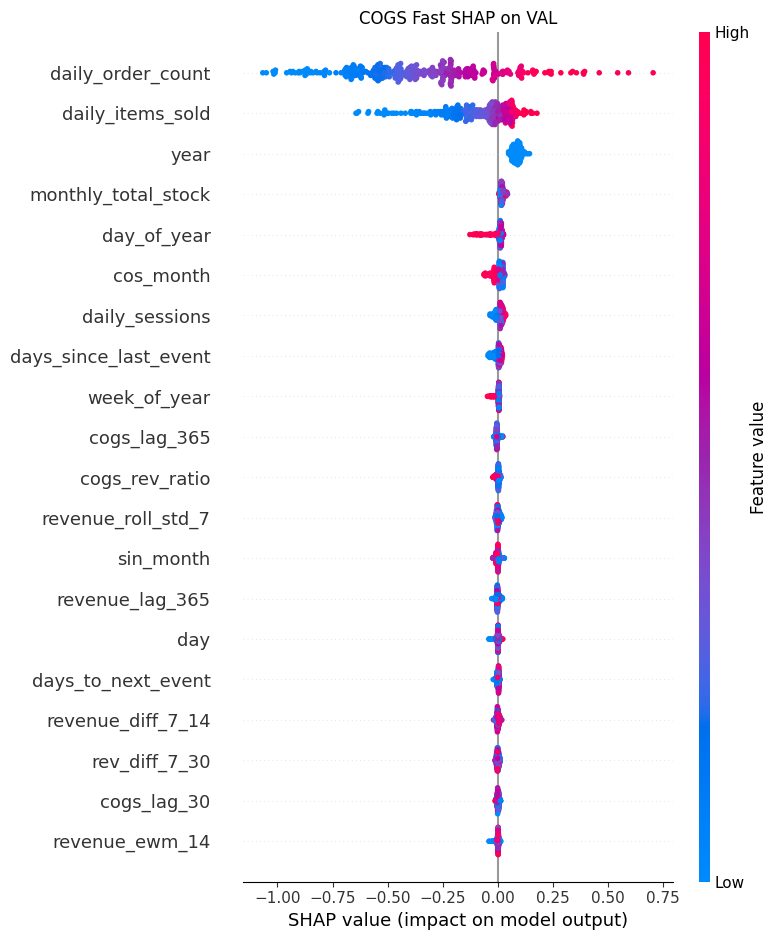

22:50:30 INFO     Feature selection: 45 → 33 (removed 12)


In [77]:
log.info("--- Fast Feature Selection (LGBM on full train) ---")
sel_lgb_r = LGBMRegressor(n_estimators=150, random_state=42, verbose=-1, n_jobs=-1).fit(X_train, y_train["Revenue"])
sel_lgb_c = LGBMRegressor(n_estimators=150, random_state=42, verbose=-1, n_jobs=-1).fit(X_train, y_train["COGS"])

imp_r = plot_shap(sel_lgb_r, X_val, "Revenue Fast SHAP on VAL", n=len(X_val))
imp_c = plot_shap(sel_lgb_c, X_val, "COGS Fast SHAP on VAL", n=len(X_val))

imp_combined = (imp_r/imp_r.sum() + imp_c/imp_c.sum()) / 2
n_keep = max(10, int(len(FEATURES)*0.75))
FEATURES_SEL = imp_combined.sort_values(ascending=False).head(n_keep).index.tolist()

log.info("Feature selection: %d → %d (removed %d)", len(FEATURES), len(FEATURES_SEL), len(FEATURES)-len(FEATURES_SEL))

# Update X_train / X_val to only keep selected features!
X_train = X_train[FEATURES_SEL]
X_val   = X_val[FEATURES_SEL]
FEATURES = FEATURES_SEL


## 6. Purged Walk-Forward CV & Model Factory


In [78]:
def purged_wf_splits(X, n=5, embargo=EMBARGO_DAYS):
    sz, out = len(X) // (n+1), []
    for i in range(1, n+1):
        tr_end = i * sz
        vl_st, vl_en = tr_end + embargo, min(tr_end + embargo + sz, len(X))
        if vl_st < len(X): out.append((np.arange(0,tr_end), np.arange(vl_st,vl_en)))
    return out

splits_oof  = purged_wf_splits(X_train, n=OOF_FOLDS,  embargo=EMBARGO_DAYS)
splits_tune = purged_wf_splits(X_train, n=3,           embargo=EMBARGO_DAYS)

def build_lgb(p, seed=42):  return LGBMRegressor(**p, random_state=seed, n_jobs=-1, verbose=-1)
def build_xgb(p, seed=42):  return XGBRegressor(**p, random_state=seed, n_jobs=-1, tree_method="hist", verbosity=0)
def build_cat(seed=42):
    return CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_seed=seed, verbose=0, thread_count=-1) if HAS_CATBOOST else None
def build_ridge(): return Ridge(alpha=100.0)
def build_meta():  return Ridge(alpha=1.0)


## 7. Hyperparameter Tuning


In [79]:
def _cv_mae(model_cls, p, X, y, splits):
    return np.mean([mean_absolute_error(y.iloc[vl], model_cls(**p).fit(X.iloc[tr],y.iloc[tr]).predict(X.iloc[vl])) for tr,vl in splits])

def _obj_lgb(t, X, y, sp):
    p = {"n_estimators":t.suggest_int("n",300,1000), "learning_rate":t.suggest_float("lr",0.01,0.1,log=True),
         "num_leaves":t.suggest_int("nl",20,100), "max_depth":t.suggest_int("md",3,8),
         "subsample":t.suggest_float("sb",0.6,1.0), "colsample_bytree":t.suggest_float("cb",0.6,1.0)}
    return _cv_mae(LGBMRegressor, {**p, "random_state":42, "n_jobs":-1, "verbose":-1}, X, y, sp)

def _obj_xgb(t, X, y, sp):
    p = {"n_estimators":t.suggest_int("n",300,1000), "learning_rate":t.suggest_float("lr",0.01,0.1,log=True),
         "max_depth":t.suggest_int("md",3,8), "subsample":t.suggest_float("sb",0.6,1.0),
         "colsample_bytree":t.suggest_float("cb",0.6,1.0)}
    return _cv_mae(XGBRegressor, {**p, "random_state":42, "n_jobs":-1, "tree_method":"hist","verbosity":0}, X, y, sp)

def run_study(obj, X, y, name, n=N_TRIALS):
    st = optuna.create_study(direction="minimize", sampler=TPESampler(seed=42))
    st.optimize(lambda t: obj(t, X, y, splits_tune), n_trials=n, show_progress_bar=False)
    log.info("[%s] Best CV MAE: %,.0f", name, st.best_value)
    return st.best_params

best_lgb_rev  = run_study(_obj_lgb, X_train, y_train["Revenue"], "LGB-Rev")
best_xgb_rev  = run_study(_obj_xgb, X_train, y_train["Revenue"], "XGB-Rev")
best_lgb_cogs = run_study(_obj_lgb, X_train, y_train["COGS"], "LGB-Cogs")
best_xgb_cogs = run_study(_obj_xgb, X_train, y_train["COGS"], "XGB-Cogs")


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\Khang\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Khang\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Khang\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Khang\AppData\Local\Programs\Python\Python311\Lib\logging\__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
ValueError: unsupported format character ',' (0x2c) at index 19
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "d:\Datathon\venv\Lib\site-packages\ipykernel_launcher.py", li

## 8. OOF Generation & Meta-Model


In [80]:
_oof_cols = ["lgb","xgb","ridge"] + (["cat"] if HAS_CATBOOST else [])
oof_rev  = pd.DataFrame(np.nan, index=X_train.index, columns=_oof_cols)
oof_cogs = pd.DataFrame(np.nan, index=X_train.index, columns=_oof_cols)

for fold, (tr_i, vl_i) in enumerate(splits_oof):
    Xt, Xv = X_train.iloc[tr_i], X_train.iloc[vl_i]
    yt_r, yt_c = y_train["Revenue"].iloc[tr_i], y_train["COGS"].iloc[tr_i]
    sc = StandardScaler(); Xt_sc=sc.fit_transform(Xt); Xv_sc=sc.transform(Xv)

    m_lgb_r = build_lgb(best_lgb_rev).fit(Xt, yt_r); m_xgb_r = build_xgb(best_xgb_rev).fit(Xt, yt_r)
    m_rid_r = build_ridge().fit(Xt_sc, yt_r)
    oof_rev.loc[X_train.index[vl_i], "lgb"] = m_lgb_r.predict(Xv)
    oof_rev.loc[X_train.index[vl_i], "xgb"] = m_xgb_r.predict(Xv)
    oof_rev.loc[X_train.index[vl_i], "ridge"] = m_rid_r.predict(Xv_sc)
    if HAS_CATBOOST: oof_rev.loc[X_train.index[vl_i],"cat"] = build_cat().fit(Xt, yt_r).predict(Xv)

    m_lgb_c = build_lgb(best_lgb_cogs).fit(Xt, yt_c); m_xgb_c = build_xgb(best_xgb_cogs).fit(Xt, yt_c)
    m_rid_c = build_ridge().fit(Xt_sc, yt_c)
    oof_cogs.loc[X_train.index[vl_i], "lgb"] = m_lgb_c.predict(Xv)
    oof_cogs.loc[X_train.index[vl_i], "xgb"] = m_xgb_c.predict(Xv)
    oof_cogs.loc[X_train.index[vl_i], "ridge"] = m_rid_c.predict(Xv_sc)
    if HAS_CATBOOST: oof_cogs.loc[X_train.index[vl_i],"cat"] = build_cat().fit(Xt, yt_c).predict(Xv)

# Fit Meta Model
def fit_meta(oof_df, y_true):
    active = [c for c in oof_df.columns if oof_df[c].notna().any()]
    mask = oof_df[active].notna().all(axis=1)
    meta = build_meta().fit(oof_df[mask][active], y_true[mask])
    return meta, active

meta_rev,  act_rev  = fit_meta(oof_rev,  y_train["Revenue"])
meta_cogs, act_cogs = fit_meta(oof_cogs, y_train["COGS"])
log.info("Meta weights Rev: %s", meta_rev.coef_.round(3))
log.info("Meta weights Cog: %s", meta_cogs.coef_.round(3))


22:52:56 INFO     Meta weights Rev: [ 0.161  0.108 -0.013  0.752]
22:52:56 INFO     Meta weights Cog: [ 0.297  0.141 -0.055  0.599]


## 9. Evaluation trên Val & Tìm Multiplier


In [81]:
sc_val = StandardScaler(); X_tr_sc=sc_val.fit_transform(X_train); X_vl_sc=sc_val.transform(X_val)

L_rv = build_lgb(best_lgb_rev).fit(X_train, y_train["Revenue"]); Xb_rv = build_xgb(best_xgb_rev).fit(X_train, y_train["Revenue"])
R_rv = build_ridge().fit(X_tr_sc, y_train["Revenue"]); C_rv = build_cat().fit(X_train, y_train["Revenue"]) if HAS_CATBOOST else None

L_cv = build_lgb(best_lgb_cogs).fit(X_train, y_train["COGS"]); Xb_cv = build_xgb(best_xgb_cogs).fit(X_train, y_train["COGS"])
R_cv = build_ridge().fit(X_tr_sc, y_train["COGS"]); C_cv = build_cat().fit(X_train, y_train["COGS"]) if HAS_CATBOOST else None

def _get_L0(L, Xb, R, C, X, X_sc, act):
    mp = {"lgb":L.predict(X), "xgb":Xb.predict(X), "ridge":R.predict(X_sc)}
    if C: mp["cat"] = C.predict(X)
    return np.column_stack([mp[c] for c in act])

pred_rev = inverse_transform(meta_rev.predict(_get_L0(L_rv, Xb_rv, R_rv, C_rv, X_val, X_vl_sc, act_rev)))
pred_cog = inverse_transform(meta_cogs.predict(_get_L0(L_cv, Xb_cv, R_cv, C_cv, X_val, X_vl_sc, act_cogs)))

log.info("--- Trước Multiplier ---")
evaluate(y_val["Revenue"], pred_rev, "Val-Rev-Raw")
evaluate(y_val["COGS"],    pred_cog, "Val-Cog-Raw")

log.info("--- Tìm Multiplier ---")
k_rev  = tune_multiplier(y_val["Revenue"], pred_rev)
k_cogs = tune_multiplier(y_val["COGS"],    pred_cog)

log.info("--- Sau Multiplier ---")
evaluate(y_val["Revenue"], pred_rev * k_rev, "Val-Rev-Final")
evaluate(y_val["COGS"],    pred_cog * k_cogs, "Val-Cog-Final")


22:52:59 INFO     --- Trước Multiplier ---
22:52:59 INFO     Val-Rev-Raw       MAE=     226,685  RMSE=     290,081  R2=0.9700
22:52:59 INFO     Val-Cog-Raw       MAE=     201,509  RMSE=     261,286  R2=0.9679
22:52:59 INFO     --- Tìm Multiplier ---
22:52:59 INFO       Multiplier k=1.0080  MAE_before=226,685  after=226,144
22:52:59 INFO       Multiplier k=0.9920  MAE_before=201,509  after=200,358
22:52:59 INFO     --- Sau Multiplier ---
22:52:59 INFO     Val-Rev-Final     MAE=     226,144  RMSE=     289,181  R2=0.9702
22:52:59 INFO     Val-Cog-Final     MAE=     200,358  RMSE=     260,086  R2=0.9682


{'mae': 200358.0887017178, 'rmse': 260085.7816155152, 'r2': 0.9682034334738778}

## 10. Final Retrain, Covariate Imputation & Submission (Seed Avg, Multiplier Out of Loop)


In [82]:
# ── Retrain ──────────────────────────────────────────
SEEDS = [42, 2026, 9999]
df_full = df[df.Date <= FULL_END].dropna(subset=["revenue_lag_365"]).copy()
X_full, y_full_t = df_full[FEATURES], df_full[TARGETS].apply(transform_target)
sc_full = StandardScaler(); X_full_sc = sc_full.fit_transform(X_full)

SUB_PATH = DATA_DIR / "sample_submission.csv"
if not SUB_PATH.exists():
    log.warning("Không tìm thấy sample_submission.csv!")
else:
    test_dates = pd.read_csv(SUB_PATH, parse_dates=["Date"])["Date"].values
    all_rv, all_cg = [], []

    for SEED in SEEDS:
        log.info("=== Retrain L0 - Seed %d ===", SEED)
        L_rf = LGBMRegressor(**{**best_lgb_rev,"random_state":SEED,"n_jobs":-1,"verbose":-1}).fit(X_full, y_full_t["Revenue"])
        Xb_rf = XGBRegressor(**{**best_xgb_rev,"random_state":SEED,"n_jobs":-1,"tree_method":"hist","verbosity":0}).fit(X_full, y_full_t["Revenue"])
        
        L_cf = LGBMRegressor(**{**best_lgb_cogs,"random_state":SEED,"n_jobs":-1,"verbose":-1}).fit(X_full, y_full_t["COGS"])
        Xb_cf = XGBRegressor(**{**best_xgb_cogs,"random_state":SEED,"n_jobs":-1,"tree_method":"hist","verbosity":0}).fit(X_full, y_full_t["COGS"])
        
        df_ext = df_full.copy()
        pr_l, pc_l = [], []

        for i, date in enumerate(test_dates):
            # 1. Khởi tạo dòng tương lai
            new_row = pd.DataFrame({"Date":[date], "Revenue":[0.], "COGS":[0.]})
            df_ext = pd.concat([df_ext, new_row], ignore_index=True)
            
            # 2. FIX CHÍ MẠNG: Dùng Forward Fill để copy momentum ngày hôm qua cho TẤT CẢ external features
            cols_to_ffill = [c for c in df_ext.columns if c not in ["Date", "Revenue", "COGS"]]
            df_ext[cols_to_ffill] = df_ext[cols_to_ffill].ffill()
            
            # 3. Ép cờ Promo nếu rơi vào ngày sự kiện
            if pd.Timestamp(date) in SHOPPING_EVENTS and "active_promo_count" in df_ext.columns:
                df_ext.loc[df_ext.index[-1], "active_promo_count"] = 1.0
            
            # 4. Prepare Features (Lúc này df_ext đã sạch 100% NaN)
            row_raw = feature_eng.prepare_recursive_features(df_ext)
            Xr = row_raw[FEATURES]

            # 5. Simple Blending (Chỉ dùng LGBM và XGBoost, an toàn hơn)
            pred_r_lgb = L_rf.predict(Xr)
            pred_r_xgb = Xb_rf.predict(Xr)
            pr = inverse_transform(np.mean([pred_r_lgb, pred_r_xgb])) 
            
            pred_c_lgb = L_cf.predict(Xr)
            pred_c_xgb = Xb_cf.predict(Xr)
            pc = inverse_transform(np.mean([pred_c_lgb, pred_c_xgb])) 

            # Cập nhật kết quả đệ quy
            pr_l.append(pr)
            pc_l.append(pc)
            df_ext.loc[df_ext.index[-1], ["Revenue","COGS"]] = [pr, pc]

            if (i+1)%50==0: log.info("  Seed %d: Forecasted %d/%d", SEED, i+1, len(test_dates))

        # 6. Tuyệt đối KHÔNG NHÂN MULTIPLIER Ở ĐÂY NỮA
        all_rv.append(pr_l)
        all_cg.append(pc_l)

    # Average
    sub = pd.DataFrame({"Date":[pd.Timestamp(d).strftime("%Y-%m-%d") for d in test_dates],
                        "Revenue":np.mean(all_rv,axis=0), "COGS":np.mean(all_cg,axis=0)})
    sub.to_csv("submission.csv", index=False)
    log.info("✅ submission.csv ready! (Averaged 3 seeds)")
    display(sub.head())


22:52:59 INFO     === Retrain L0 - Seed 42 ===
22:53:04 INFO       Seed 42: Forecasted 50/548
22:53:08 INFO       Seed 42: Forecasted 100/548
22:53:12 INFO       Seed 42: Forecasted 150/548
22:53:16 INFO       Seed 42: Forecasted 200/548
22:53:20 INFO       Seed 42: Forecasted 250/548
22:53:24 INFO       Seed 42: Forecasted 300/548
22:53:29 INFO       Seed 42: Forecasted 350/548
22:53:33 INFO       Seed 42: Forecasted 400/548
22:53:37 INFO       Seed 42: Forecasted 450/548
22:53:42 INFO       Seed 42: Forecasted 500/548
22:53:46 INFO     === Retrain L0 - Seed 2026 ===
22:53:51 INFO       Seed 2026: Forecasted 50/548
22:53:55 INFO       Seed 2026: Forecasted 100/548
22:53:59 INFO       Seed 2026: Forecasted 150/548
22:54:03 INFO       Seed 2026: Forecasted 200/548
22:54:07 INFO       Seed 2026: Forecasted 250/548
22:54:11 INFO       Seed 2026: Forecasted 300/548
22:54:15 INFO       Seed 2026: Forecasted 350/548
22:54:20 INFO       Seed 2026: Forecasted 400/548
22:54:24 INFO       Seed 2

,Date,Revenue,COGS
0,2023-01-01,1.962939e+06,2.064461e+06
1,2023-01-02,2.049873e+06,2.191486e+06
2,2023-01-03,2.084938e+06,2.137248e+06
3,2023-01-04,2.087911e+06,2.198557e+06
4,2023-01-05,2.224521e+06,2.285347e+06
